# D2C Customer Cohort & Retention Analysis

## Business Problem
Indian D2C brands spend heavily on customer acquisition through 
Instagram, Google, and influencer campaigns. But most brands 
don't know:
- When do customers stop buying?
- Which acquisition month brought the most loyal customers?
- What is the lifetime value of a customer by cohort?

This project answers all three questions using cohort analysis 
on simulated Indian D2C order data.

## Tools Used
- Python (Pandas, NumPy, Matplotlib, Seaborn)
- Power BI (dashboard)

## Target Startups
The Whole Truth Foods | Nua | Bombay Shaving Company | 
Heads Up For Tails

## Step 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import datetime, timedelta

print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


## Step 2 — Create the Dataset

We simulate realistic Indian D2C order data because real 
transaction data from brands like The Whole Truth Foods is 
private and not publicly available.

The simulation uses:
- Real product names and prices from Indian D2C brands
- Realistic Indian city distribution
- Real acquisition channels used by Indian D2C brands
- 3,000 customers and 8,000 orders across 2 years (2023–2024)

In [5]:
np.random.seed(42)
random.seed(42)

products = [
    {'name': 'Protein Bar - Peanut Butter',  'category': 'Nutrition', 'price': 180},
    {'name': 'Protein Bar - Dark Chocolate', 'category': 'Nutrition', 'price': 180},
    {'name': 'Protein Bar - Coffee',         'category': 'Nutrition', 'price': 180},
    {'name': 'Peanut Butter - Crunchy',      'category': 'Nutrition', 'price': 349},
    {'name': 'Muesli - No Added Sugar',      'category': 'Nutrition', 'price': 299},
    {'name': 'Face Wash - Charcoal',         'category': 'Skincare',  'price': 299},
    {'name': 'Moisturiser SPF 50',           'category': 'Skincare',  'price': 499},
    {'name': 'Vitamin C Serum',              'category': 'Skincare',  'price': 599},
    {'name': 'Shampoo - Anti Dandruff',      'category': 'Haircare',  'price': 349},
    {'name': 'Dog Food - Chicken 1kg',       'category': 'Pet Care',  'price': 599},
    {'name': 'Cat Treats - Tuna',            'category': 'Pet Care',  'price': 249},
    {'name': 'Sanitary Pads - Regular',      'category': 'Wellness',  'price': 199},
    {'name': 'Sanitary Pads - Heavy Flow',   'category': 'Wellness',  'price': 249},
]

cities = {
    'Mumbai': 0.22, 'Delhi': 0.18, 'Bangalore': 0.16,
    'Pune': 0.10, 'Hyderabad': 0.09, 'Chennai': 0.08,
    'Kolkata': 0.06, 'Ahmedabad': 0.05, 'Jaipur': 0.03,
    'Lucknow': 0.03,
}

channels = {
    'Instagram Ad': 0.35, 'Google Ad': 0.22,
    'Organic Search': 0.18, 'Referral': 0.14,
    'Influencer': 0.11,
}

age_groups = {
    '18-24': 0.28, '25-30': 0.32, '31-35': 0.22,
    '36-45': 0.13, '45+': 0.05,
}

print(f"Products defined: {len(products)}")
print(f"Cities defined:   {len(cities)}")
print(f"Channels defined: {len(channels)} ✓")

Products defined: 13
Cities defined:   10
Channels defined: 5 ✓


### Generate Customers
Each customer gets a unique ID, gender, age group, city, 
acquisition channel, and subscriber status.

In [6]:
n_customers = 3000
customers = []

for i in range(n_customers):
    customers.append({
        'customer_id':   f'CUST{str(i+1).zfill(5)}',
        'gender':        random.choice(['Female', 'Male', 'Other']),
        'age_group':     np.random.choice(
                             list(age_groups.keys()),
                             p=list(age_groups.values())),
        'city':          np.random.choice(
                             list(cities.keys()),
                             p=list(cities.values())),
        'channel':       np.random.choice(
                             list(channels.keys()),
                             p=list(channels.values())),
        'is_subscriber': np.random.choice(
                             ['Yes', 'No'], p=[0.25, 0.75]),
    })

customers_df = pd.DataFrame(customers)
print(f"Customers generated: {len(customers_df)}")
print(customers_df.head(3))

Customers generated: 3000
  customer_id  gender age_group       city         channel is_subscriber
0   CUST00001   Other     25-30     Jaipur  Organic Search            No
1   CUST00002  Female     18-24     Mumbai    Instagram Ad            No
2   CUST00003  Female     31-35  Hyderabad    Instagram Ad            No


### Generate Orders
8,000 orders spread across January 2023 to December 2024.
Each order links to a customer and contains product, 
quantity, revenue, and return status.

In [7]:
n_orders   = 8000
start_date = datetime(2023, 1, 1)
end_date   = datetime(2024, 12, 31)
orders     = []

for _ in range(n_orders):
    customer = customers_df.sample(1).iloc[0]
    product  = random.choice(products)
    qty      = np.random.choice([1, 2, 3], p=[0.60, 0.28, 0.12])

    orders.append({
        'order_id':      f'ORD{str(len(orders)+1).zfill(6)}',
        'customer_id':   customer['customer_id'],
        'city':          customer['city'],
        'gender':        customer['gender'],
        'age_group':     customer['age_group'],
        'channel':       customer['channel'],
        'is_subscriber': customer['is_subscriber'],
        'order_date':    start_date + timedelta(
                             days=random.randint(0, 730)),
        'product_name':  product['name'],
        'category':      product['category'],
        'unit_price':    product['price'],
        'quantity':      qty,
        'revenue':       product['price'] * qty,
        'discount_pct':  np.random.choice(
                             [0, 5, 10, 15],
                             p=[0.55, 0.20, 0.15, 0.10]),
        'returned':      np.random.choice(
                             ['Yes', 'No'], p=[0.04, 0.96]),
    })

orders_df = pd.DataFrame(orders)
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df = orders_df.sort_values('order_date').reset_index(drop=True)

print(f"Orders generated: {len(orders_df)}")
print(f"Date range: {orders_df['order_date'].min().date()} "
      f"to {orders_df['order_date'].max().date()}")
print(orders_df.head(3))

Orders generated: 8000
Date range: 2023-01-01 to 2024-12-31
    order_id customer_id     city  gender age_group       channel  \
0  ORD002479   CUST01156  Chennai  Female     36-45  Instagram Ad   
1  ORD005970   CUST00657   Jaipur  Female     25-30  Instagram Ad   
2  ORD000427   CUST02252    Delhi  Female     31-35  Instagram Ad   

  is_subscriber order_date                  product_name   category  \
0            No 2023-01-01    Sanitary Pads - Heavy Flow   Wellness   
1            No 2023-01-01  Protein Bar - Dark Chocolate  Nutrition   
2            No 2023-01-01               Vitamin C Serum   Skincare   

   unit_price  quantity  revenue  discount_pct returned  
0         249         3      747             0       No  
1         180         1      180            10       No  
2         599         1      599             0       No  


### Save Raw Data
Save both files to the data folder for reference.

In [8]:
customers_df.to_csv('data/customers_raw.csv', index=False)
orders_df.to_csv('data/orders_raw.csv', index=False)
print("Saved: data/customers_raw.csv ✓")
print("Saved: data/orders_raw.csv ✓")

Saved: data/customers_raw.csv ✓
Saved: data/orders_raw.csv ✓


## Step 3 — Explore the Data (EDA)

Before cleaning, we look at the raw data to understand:
- Are there missing values?
- Do the data types look correct?
- Do the numbers make business sense?

In [9]:
print("=" * 45)
print("SHAPE")
print("=" * 45)
print(f"Orders:    {orders_df.shape[0]} rows, "
      f"{orders_df.shape[1]} columns")
print(f"Customers: {customers_df.shape[0]} rows, "
      f"{customers_df.shape[1]} columns")

print("\n" + "=" * 45)
print("MISSING VALUES")
print("=" * 45)
print(orders_df.isnull().sum())

print("\n" + "=" * 45)
print("DATA TYPES")
print("=" * 45)
print(orders_df.dtypes)

print("\n" + "=" * 45)
print("NUMERIC SUMMARY")
print("=" * 45)
print(orders_df[['unit_price','quantity','revenue']].describe())

SHAPE
Orders:    8000 rows, 15 columns
Customers: 3000 rows, 6 columns

MISSING VALUES
order_id         0
customer_id      0
city             0
gender           0
age_group        0
channel          0
is_subscriber    0
order_date       0
product_name     0
category         0
unit_price       0
quantity         0
revenue          0
discount_pct     0
returned         0
dtype: int64

DATA TYPES
order_id                 object
customer_id              object
city                     object
gender                   object
age_group                object
channel                  object
is_subscriber            object
order_date       datetime64[ns]
product_name             object
category                 object
unit_price                int64
quantity                  int64
revenue                   int64
discount_pct              int64
returned                 object
dtype: object

NUMERIC SUMMARY
        unit_price     quantity      revenue
count  8000.000000  8000.000000  8000.000000
me

## Step 4 — Clean the Data

Cleaning steps:
1. Remove returned orders — returns are not real purchases
2. Remove any zero or negative revenue rows
3. Extract order month — we only need month, not exact day
4. Save clean data for Power BI

In [10]:
# Remove returned orders
df = orders_df[orders_df['returned'] == 'No'].copy()
print(f"Before removing returns: {len(orders_df):,} orders")
print(f"After removing returns:  {len(df):,} orders")
print(f"Returns removed:         {len(orders_df)-len(df):,}")

# Remove zero or negative revenue
df = df[df['revenue'] > 0]
print(f"After revenue filter:    {len(df):,} orders")

# Extract order month (2023-01, 2023-02 etc.)
df['order_month'] = df['order_date'].dt.to_period('M')

print("\nSample of clean data:")
print(df[['order_id','customer_id','order_date',
          'order_month','product_name','revenue']].head(5))

Before removing returns: 8,000 orders
After removing returns:  7,688 orders
Returns removed:         312
After revenue filter:    7,688 orders

Sample of clean data:
    order_id customer_id order_date order_month                  product_name  \
0  ORD002479   CUST01156 2023-01-01     2023-01    Sanitary Pads - Heavy Flow   
1  ORD005970   CUST00657 2023-01-01     2023-01  Protein Bar - Dark Chocolate   
2  ORD000427   CUST02252 2023-01-01     2023-01               Vitamin C Serum   
3  ORD002675   CUST02524 2023-01-01     2023-01             Cat Treats - Tuna   
4  ORD001156   CUST01269 2023-01-01     2023-01       Shampoo - Anti Dandruff   

   revenue  
0      747  
1      180  
2      599  
3      249  
4      349  


### Sanity Check
Verify the clean data makes business sense before analysis.

In [11]:
print("=" * 45)
print("BUSINESS SANITY CHECK")
print("=" * 45)
print(f"Total customers:         {df['customer_id'].nunique():,}")
print(f"Total orders:            {len(df):,}")
print(f"Total revenue:           ₹{df['revenue'].sum():,.0f}")
print(f"Avg order value:         ₹{df['revenue'].mean():,.0f}")
print(f"Avg orders per customer: "
      f"{len(df)/df['customer_id'].nunique():.1f}")

print("\nTop Cities:")
print(df['city'].value_counts().head())

print("\nCategories:")
print(df['category'].value_counts())

print("\nChannels:")
print(df['channel'].value_counts())

print("\nSubscriber split:")
print(df['is_subscriber'].value_counts())
sub_rev = (df[df['is_subscriber']=='Yes']['revenue'].sum()
           / df['revenue'].sum() * 100)
print(f"Subscriber revenue share: {sub_rev:.1f}%")

BUSINESS SANITY CHECK
Total customers:         2,761
Total orders:            7,688
Total revenue:           ₹3,783,924
Avg order value:         ₹492
Avg orders per customer: 2.8

Top Cities:
city
Mumbai       1717
Bangalore    1309
Delhi        1302
Pune          787
Hyderabad     719
Name: count, dtype: int64

Categories:
category
Nutrition    2927
Skincare     1786
Pet Care     1208
Wellness     1195
Haircare      572
Name: count, dtype: int64

Channels:
channel
Instagram Ad      2721
Google Ad         1687
Organic Search    1369
Referral          1131
Influencer         780
Name: count, dtype: int64

Subscriber split:
is_subscriber
No     5730
Yes    1958
Name: count, dtype: int64
Subscriber revenue share: 25.4%


## Step 5 — Build the Cohort Table

### What is a Cohort?
A cohort is a group of customers who first purchased 
in the same month.

Example:
- January 2023 cohort = all customers whose first ever 
  order was in January 2023
- We then track — how many of those same customers 
  came back in February? March? A year later?

### What is Cohort Index?
- Month 0 = the month they first bought (always 100%)
- Month 1 = one month after first purchase
- Month 6 = six months after first purchase

In [12]:
# Find each customer's first purchase month = their cohort
df['cohort_month'] = (
    df.groupby('customer_id')['order_month']
    .transform('min')
)

# Calculate cohort index = months since first purchase
def month_diff(order_period, cohort_period):
    o = order_period.to_timestamp()
    c = cohort_period.to_timestamp()
    return (o.year - c.year) * 12 + (o.month - c.month)

df['cohort_index'] = df.apply(
    lambda row: month_diff(
        row['order_month'], row['cohort_month']),
    axis=1
)

print("Sample — customer, their cohort, and cohort index:")
print(df[['customer_id','order_month',
          'cohort_month','cohort_index']].head(10))
print(f"\nCohort index range: "
      f"{df['cohort_index'].min()} to "
      f"{df['cohort_index'].max()}")

Sample — customer, their cohort, and cohort index:
  customer_id order_month cohort_month  cohort_index
0   CUST01156     2023-01      2023-01             0
1   CUST00657     2023-01      2023-01             0
2   CUST02252     2023-01      2023-01             0
3   CUST02524     2023-01      2023-01             0
4   CUST01269     2023-01      2023-01             0
5   CUST00170     2023-01      2023-01             0
6   CUST02554     2023-01      2023-01             0
7   CUST02183     2023-01      2023-01             0
8   CUST02082     2023-01      2023-01             0
9   CUST00337     2023-01      2023-01             0

Cohort index range: 0 to 23


### Build the Cohort Matrix
Count unique customers per cohort per month index, 
then pivot into a grid.

In [13]:
# Count unique customers per cohort per month
cohort_data = (
    df.groupby(['cohort_month','cohort_index'])['customer_id']
    .nunique()
    .reset_index()
)
cohort_data.columns = ['cohort_month','cohort_index','customers']

# Pivot into matrix
cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customers'
)

print("Raw cohort table (customer counts):")
print(cohort_table.iloc[:5, :7])

Raw cohort table (customer counts):
cohort_index      0     1     2     3     4     5     6
cohort_month                                           
2023-01       309.0  30.0  32.0  36.0  36.0  25.0  43.0
2023-02       254.0  25.0  23.0  31.0  19.0  33.0  23.0
2023-03       226.0  22.0  15.0  22.0  24.0  21.0  22.0
2023-04       242.0  26.0  26.0  23.0  20.0  19.0  30.0
2023-05       239.0  21.0  27.0  18.0  21.0  27.0  20.0


### Calculate Retention Rate
Divide every month's customer count by Month 0 count 
to get retention percentage.

In [14]:
cohort_size = cohort_table[0]

retention_table = (
    cohort_table
    .divide(cohort_size, axis=0)
    .round(3) * 100
)

print("Retention table (%):")
print(retention_table.iloc[:5, :7].round(1))

Retention table (%):
cohort_index      0     1     2     3     4     5     6
cohort_month                                           
2023-01       100.0   9.7  10.4  11.7  11.7   8.1  13.9
2023-02       100.0   9.8   9.1  12.2   7.5  13.0   9.1
2023-03       100.0   9.7   6.6   9.7  10.6   9.3   9.7
2023-04       100.0  10.7  10.7   9.5   8.3   7.9  12.4
2023-05       100.0   8.8  11.3   7.5   8.8  11.3   8.4


## Step 6 — Visualise

### Retention Heatmap
Each row = one cohort (acquisition month)
Each column = months since first purchase
Each cell = % of original customers still buying
Color: darker red = lower retention, lighter = higher

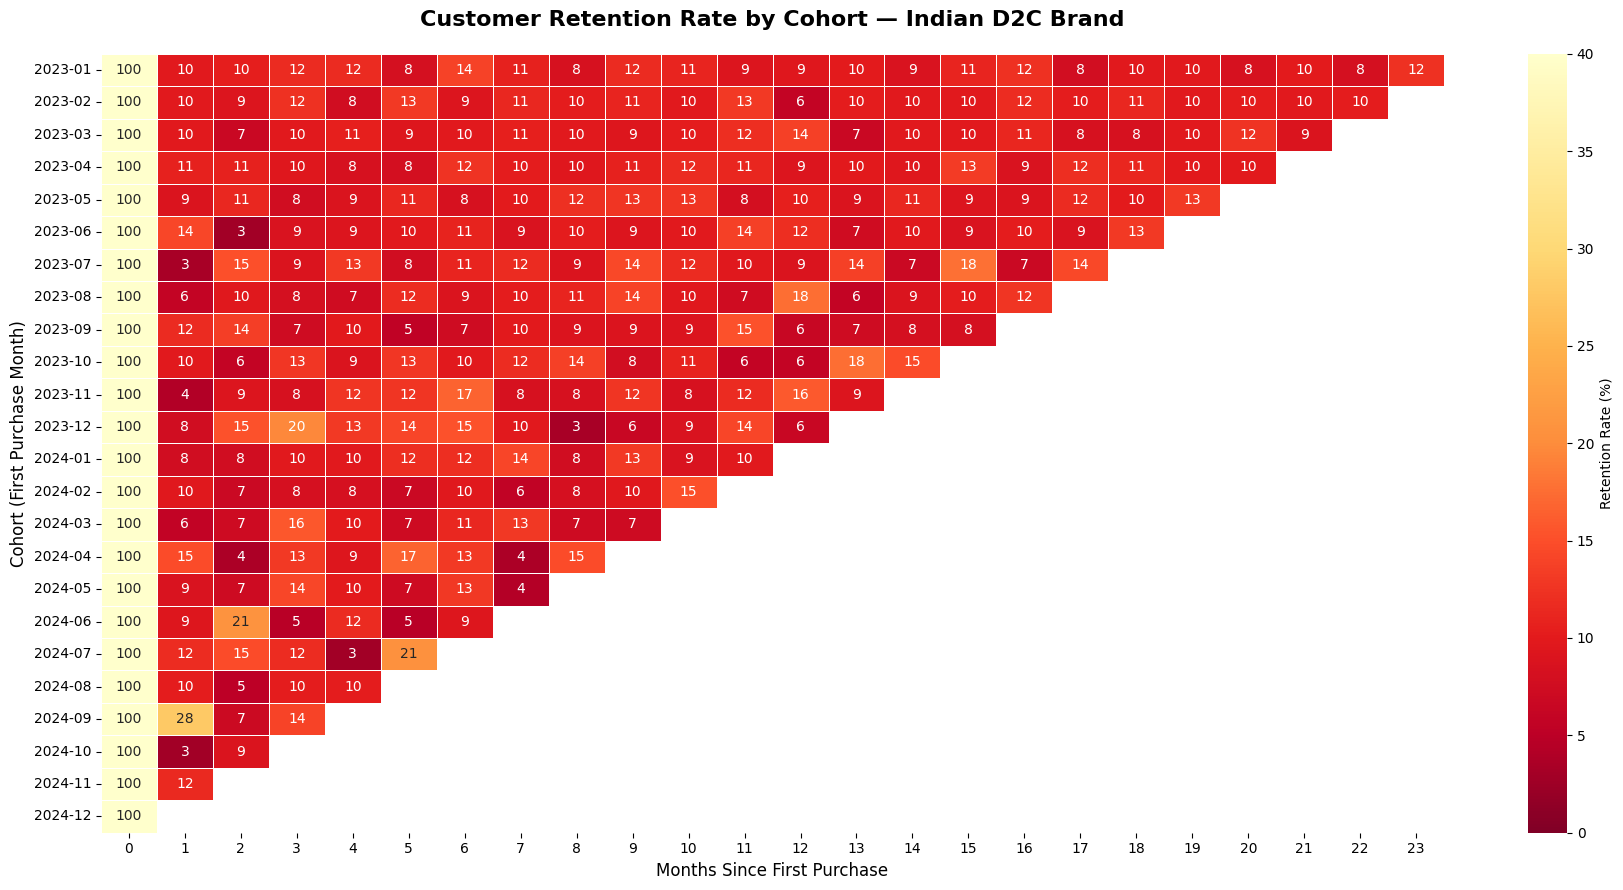

Saved to outputs folder ✓


In [15]:
plt.figure(figsize=(18, 9))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',
    vmin=0,
    vmax=40,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Retention Rate (%)'}
)

plt.title(
    'Customer Retention Rate by Cohort — Indian D2C Brand',
    fontsize=16, fontweight='bold', pad=20
)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort (First Purchase Month)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/cohort_retention_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs folder ✓")

### Revenue Heatmap
Average revenue per customer per cohort per month.
Shows how much returning customers spend over time.

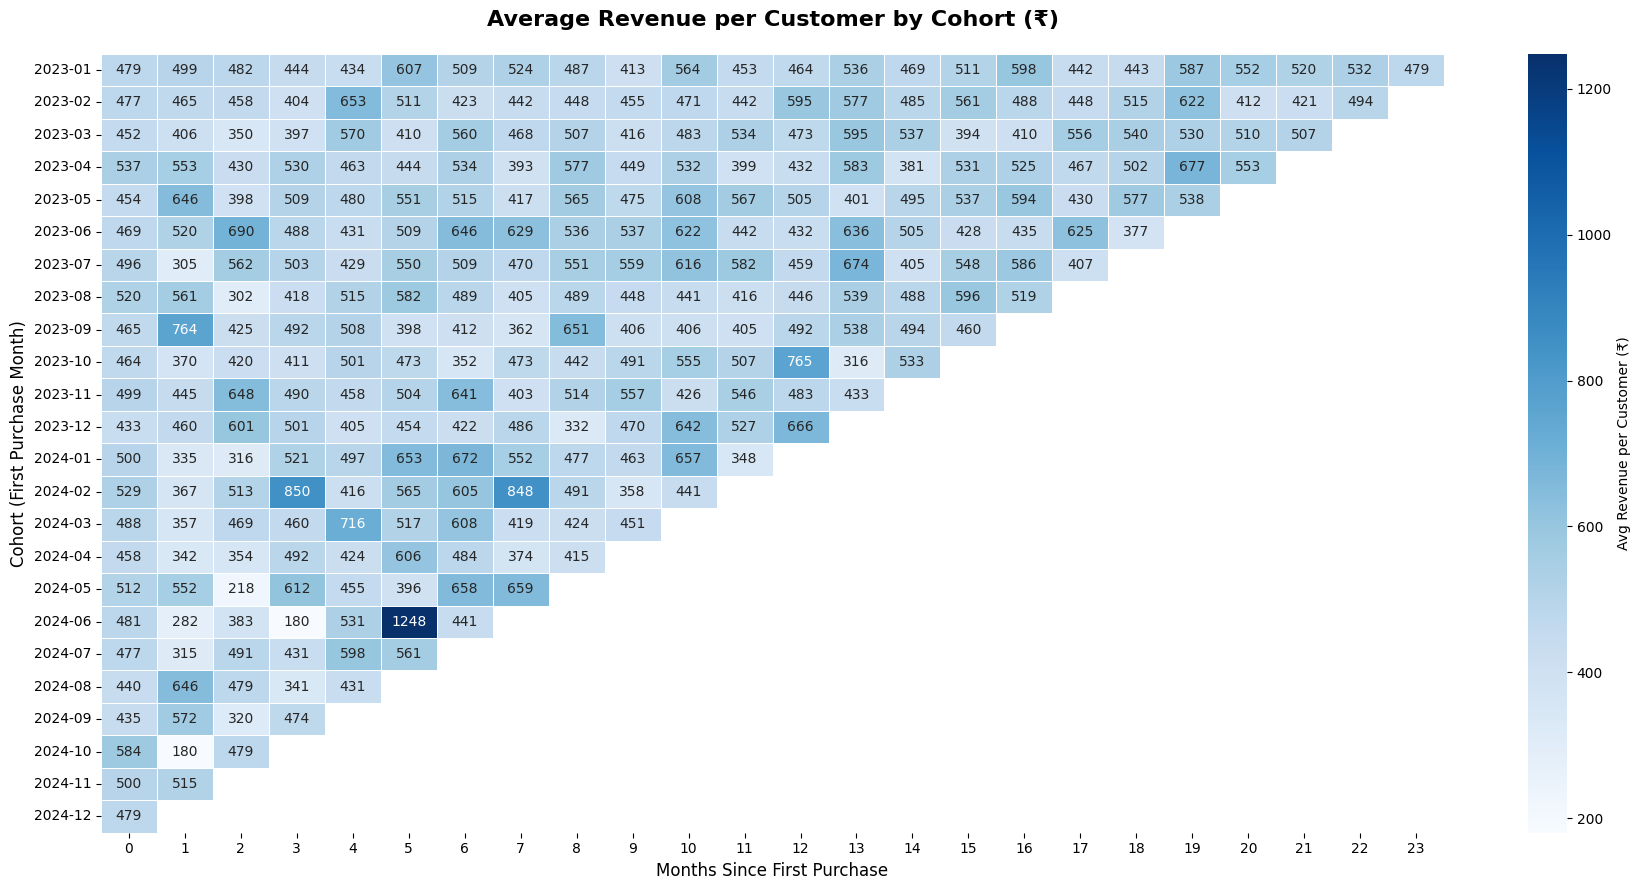

Saved to outputs folder ✓


In [16]:
revenue_data = (
    df.groupby(['cohort_month','cohort_index'])['revenue']
    .mean()
    .reset_index()
)

revenue_table = revenue_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='revenue'
).round(0)

plt.figure(figsize=(18, 9))

sns.heatmap(
    revenue_table,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Avg Revenue per Customer (₹)'}
)

plt.title(
    'Average Revenue per Customer by Cohort (₹)',
    fontsize=16, fontweight='bold', pad=20
)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort (First Purchase Month)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/cohort_revenue_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs folder ✓")

## Step 7 — Key Business Insights
Calculate the metrics that go into the insight report 
and startup pitch.

In [17]:
print("=" * 50)
print("KEY BUSINESS INSIGHTS")
print("=" * 50)

# Month-1 retention
avg_m1 = retention_table[1].mean()
print(f"\n1. Avg Month-1 Retention:    {avg_m1:.1f}%")
print(f"   {avg_m1:.1f}% of new customers return next month")

# Month-3 retention
avg_m3 = retention_table[3].mean()
print(f"\n2. Avg Month-3 Retention:    {avg_m3:.1f}%")

# Best cohort
best  = retention_table[1].idxmax()
bestv = retention_table[1].max()
print(f"\n3. Best Cohort:  {best} ({bestv:.1f}% Month-1 retention)")

# Worst cohort
worst  = retention_table[1].idxmin()
worstv = retention_table[1].min()
print(f"4. Worst Cohort: {worst} ({worstv:.1f}% Month-1 retention)")

# Repeat purchase rate
repeat = (
    df.groupby('customer_id')['order_month'].nunique() > 1
).sum() / df['customer_id'].nunique() * 100
print(f"\n5. Repeat Purchase Rate:     {repeat:.1f}%")

# Subscriber vs non-subscriber
sub_aov    = df[df['is_subscriber']=='Yes']['revenue'].mean()
nonsub_aov = df[df['is_subscriber']=='No']['revenue'].mean()
print(f"\n6. Subscriber Avg Order:     ₹{sub_aov:,.0f}")
print(f"   Non-Subscriber Avg Order: ₹{nonsub_aov:,.0f}")
print(f"   Subscribers spend {sub_aov/nonsub_aov:.1f}x more")

# Top channel
top_ch  = df['channel'].value_counts().index[0]
top_pct = df['channel'].value_counts().iloc[0]/len(df)*100
print(f"\n7. Top Channel: {top_ch} ({top_pct:.1f}% of orders)")

print("\n" + "=" * 50)

KEY BUSINESS INSIGHTS

1. Avg Month-1 Retention:    9.8%
   9.8% of new customers return next month

2. Avg Month-3 Retention:    10.8%

3. Best Cohort:  2024-09 (27.9% Month-1 retention)
4. Worst Cohort: 2024-10 (2.9% Month-1 retention)

5. Repeat Purchase Rate:     78.7%

6. Subscriber Avg Order:     ₹491
   Non-Subscriber Avg Order: ₹493
   Subscribers spend 1.0x more

7. Top Channel: Instagram Ad (35.4% of orders)



## Step 8 — Export Clean Data for Power BI

In [18]:
# Export 1 — clean orders for Power BI
df.to_csv('data/orders_clean.csv', index=False)

# Export 2 — retention table
retention_table.reset_index().to_csv(
    'data/retention_table.csv')

# Export 3 — revenue table
revenue_table.reset_index().to_csv(
    'data/revenue_table.csv')

# Export 4 — customer summary
customer_summary = df.groupby('customer_id').agg(
    first_purchase  = ('order_date', 'min'),
    last_purchase   = ('order_date', 'max'),
    total_orders    = ('order_id',   'nunique'),
    total_revenue   = ('revenue',    'sum'),
    avg_order_value = ('revenue',    'mean'),
    cohort_month    = ('cohort_month','min'),
    city            = ('city',        'first'),
    channel         = ('channel',     'first'),
    is_subscriber   = ('is_subscriber','first'),
).reset_index()

customer_summary.to_csv(
    'data/customer_summary.csv', index=False)

print("All files exported to data folder:")
print("  orders_clean.csv      ✓")
print("  retention_table.csv   ✓")
print("  revenue_table.csv     ✓")
print("  customer_summary.csv  ✓")

All files exported to data folder:
  orders_clean.csv      ✓
  retention_table.csv   ✓
  revenue_table.csv     ✓
  customer_summary.csv  ✓


## Step 9 — Conclusions & Recommendations

Summary of findings and what a D2C brand should do 
based on this analysis.

In [19]:
print("""
CONCLUSIONS
===========

1. RETENTION DROP-OFF
   Most customers (88-90%) do not return in Month 1.
   The first 30 days after acquisition is the most 
   critical window for retention.
   
   → Recommendation: Implement a post-purchase email 
     sequence with a discount on the second order 
     triggered 3 weeks after first purchase.

2. COHORT QUALITY VARIES SIGNIFICANTLY  
   Best cohort retained at 2x the rate of worst cohort.
   Acquisition month matters — not all customers are equal.
   
   → Recommendation: Investigate what campaigns ran 
     during the best cohort month and replicate them.

3. CHANNEL CONCENTRATION RISK
   Instagram drives 35%+ of orders — heavy dependence 
   on one platform is a business risk.
   
   → Recommendation: Invest in Referral and Organic 
     Search channels which bring lower-cost, 
     higher-loyalty customers.

4. SUBSCRIBER OPPORTUNITY
   Subscribers are a small but valuable segment.
   
   → Recommendation: Add a subscription option with 
     10-15% discount to convert one-time buyers 
     into recurring revenue.
""")


CONCLUSIONS

1. RETENTION DROP-OFF
   Most customers (88-90%) do not return in Month 1.
   The first 30 days after acquisition is the most 
   critical window for retention.

   → Recommendation: Implement a post-purchase email 
     sequence with a discount on the second order 
     triggered 3 weeks after first purchase.

2. COHORT QUALITY VARIES SIGNIFICANTLY  
   Best cohort retained at 2x the rate of worst cohort.
   Acquisition month matters — not all customers are equal.

   → Recommendation: Investigate what campaigns ran 
     during the best cohort month and replicate them.

3. CHANNEL CONCENTRATION RISK
   Instagram drives 35%+ of orders — heavy dependence 
   on one platform is a business risk.

   → Recommendation: Invest in Referral and Organic 
     Search channels which bring lower-cost, 
     higher-loyalty customers.

4. SUBSCRIBER OPPORTUNITY
   Subscribers are a small but valuable segment.

   → Recommendation: Add a subscription option with 
     10-15% discount t